In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
from urllib.request import urlretrieve
from IPython.display import display, Markdown, HTML, Image

In [3]:
import os
print(os.getcwd())

/Commjhub/jupyterhub/home/sphiawang/comm3180_S26/comm3180_G3_Data_Project/data_analysis/Business Schools


## The Return on Investment of a Gies and Wharton Education

The next step I took was looking at the ROI of both a Gies and Wharton education-- to specifically see when graduates are able to benefit from paying tuition. The first step was finding out how much students, on average, are paying to attend. With factors like in-state vs. out-of-state, financial aid, family contributions, I settled on a standard number of $136,800 for Gies (four year cost) and $224,984 for Wharton (four year cost). This was calculated through looking at their average financial aid offerings and overall in-state vs. out-of-state students/cost for each category.

The next step was finding out what Gies/Wharton graduates salary progression would be in the next 10 years. This data is (unsurprisingly) not publicly available; however, I knew that both schools had overwhelming concentrations in certain industries post-grad. For Gies, accounting is their best program (#1 in the nation for public schools) with the most amount of student enrollment. Gies has a notably large alumni base in Big 4 Accounting firms based in Chicago. For Wharton, IB is the most popular choice for graduates with finance being one of the top concentrations for Wharton students. Knowing this, I decided to take standardized data from 10 year salary progressions in Big 4 Accounting firms and Investment Banking firms (sources are CaseBasix and Mergers & Inquisitions), plot this progression, and see when graduates "break even".

I acknowledge that this is a heavily general form of analysis, especially because 1.) it does not reflect all Wharton/Gies graduates and 2.) assumes graduates in these industries will stay in said industry for 10+ years. For Wharton, for example, many new grads enter investment banking but pivot to private equity/buy-side 2 years later (because of even larger salary progressions). This is something that I could not account for in the data analysis.

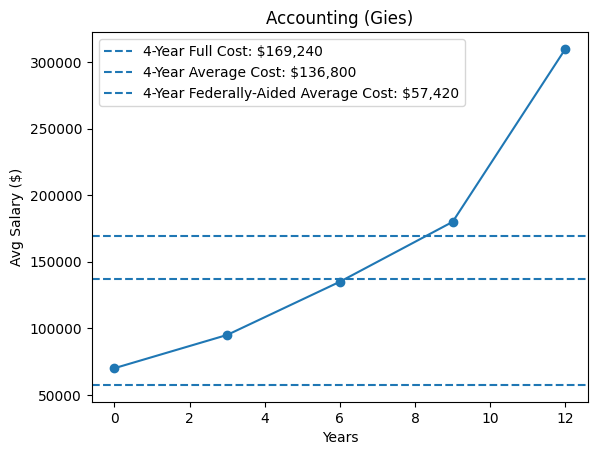

In [5]:
roi_comparison = pd.read_csv('../../data/raw/Business_Schools/salary_progressions.csv')

gies_accounting = roi_comparison[roi_comparison['Industry'] == 'Accounting']
wharton_ib = roi_comparison[roi_comparison['Industry'] == 'Investment Banking']

plt.figure()
plt.plot(gies_accounting['Year'], gies_accounting['Avg_Salary'], 'o-')
plt.axhline(y=169240, linestyle='--', label='4-Year Full Cost: $169,240')
plt.axhline(y=136800, linestyle='--', label='4-Year Average Cost: $136,800')
plt.axhline(y=57420, linestyle='--', label='4-Year Federally-Aided Average Cost: $57,420')
plt.title('Accounting (Gies)')
plt.xlabel('Years')
plt.ylabel('Avg Salary ($)')
plt.legend()
plt.show()

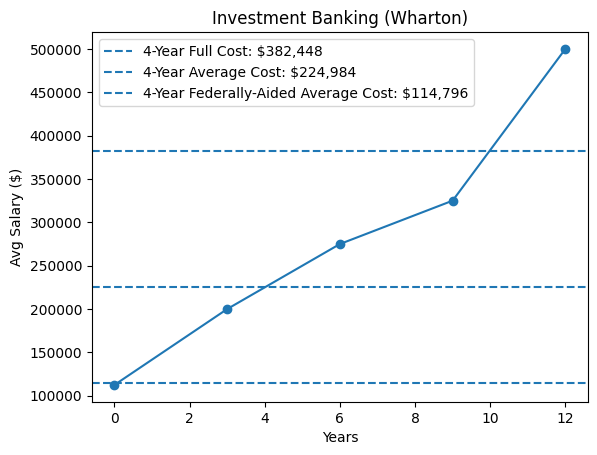

In [10]:
plt.figure()
plt.plot(wharton_ib['Year'], wharton_ib['Avg_Salary'], 'o-')
plt.axhline(y=382448, linestyle='--', label='4-Year Full Cost: $382,448')
plt.axhline(y=224984, linestyle='--', label='4-Year Average Cost: $224,984')
plt.axhline(y=114796, linestyle='--', label='4-Year Federally-Aided Average Cost: $114,796')
plt.title('Investment Banking (Wharton)')
plt.xlabel('Years')
plt.ylabel('Avg Salary ($)')
plt.legend()
plt.show()

Through this, it is clear that the majority of average Wharton students (the ones who pursue IB) have a faster ROI at around 4 years post-grad with a higher overall salary than Gies, if they stay in IB and reach the MD (Managing Director) role. Again, this data is based on what most Gies/Wharton students do post-grad and also a general number on what average costs are.

## The Cost of Attendance For Federally-Aided Students in Gies and Wharton 

Because the costs to attend above are general, I also wanted to look at costs based on family income. Using the US Department of Education's College Scorecards on UIUC and Penn, I found the cost of attendance for federally-aided students in different family income backgrounds. This data was also manually extracted from their website into an excel csv file.

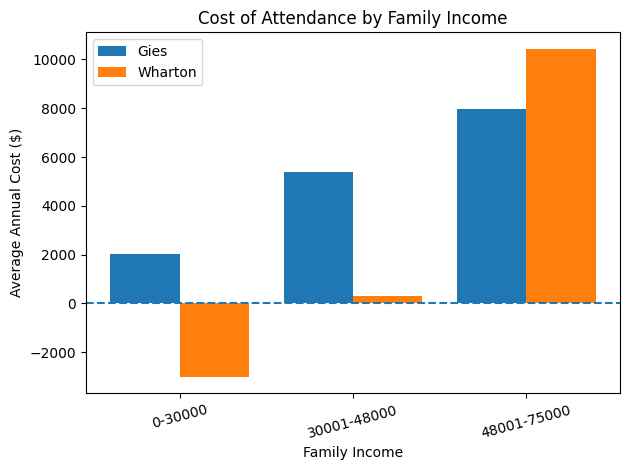

In [12]:
coa_business = pd.read_csv('../../data/raw/Business_Schools/school_costs_by_income.csv').head(3)

family_income = list(range(len(coa_business['Family_Income'])))

plt.figure()
plt.bar([i - 0.2 for i in family_income], coa_business['Gies_Annual_Cost'], width=0.4, label='Gies')
plt.bar([i + 0.2 for i in family_income], coa_business['Wharton_Annual_Cost'], width=0.4, label='Wharton')
plt.xticks(family_income, coa_business['Family_Income'], rotation=15)
plt.xlabel('Family Income')
plt.ylabel('Average Annual Cost ($)')
plt.title('Cost of Attendance by Family Income')
plt.legend()
plt.tight_layout()
plt.axhline(y=0, linestyle='--')
plt.show()

Penn is clearly strong for families of lower income as highly aided students actually receive money from Penn, rather than pay tuition. Gies follows a linear relationship in costs. Interestingly, the "wealthier" your family is at Penn, the more you will end up paying compared to Gies. 

When comparing these numbers to the graphs above, it is clear that if you are a highly aided Wharton student, and pursue IB, you will be much better off attending Wharton than Gies. 